# 03 - Classifier Validation Comparison

All conclusions here use validation only. The active discovery root is exclusively `results/publication_v2/`; V1 and the retired classifier matrix are ignored.

## 1. Discover the 24 experiment outputs

In [1]:
from pathlib import Path
import json
import sys
ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'configs').is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'notebooks/utility'))
from notebooks.utility.classifier_analysis import (build_all_validation_ensembles, compare_validation,
    discover_experiments, ensemble_metric_table, plot_ensemble_curves, plot_ensemble_overview)
inventory = discover_experiments(ROOT)
sum(row['complete'] for row in inventory), inventory

(24,
 [{'experiment_id': 'maxvit512__real_only__seed17',
   'architecture': 'maxvit512',
   'condition': 'real_only',
   'seed': 17,
   'directory': '/mnt/MammoDiffusion/MammoDiffusion/results/publication_v2/classifiers/maxvit512/real_only/seed_17',
   'training complete': True,
   'validation predictions present': True,
   'validation metrics present': True,
   'checkpoint present': True,
   'complete': True,
   'missing': []},
  {'experiment_id': 'maxvit512__real_only__seed42',
   'architecture': 'maxvit512',
   'condition': 'real_only',
   'seed': 42,
   'directory': '/mnt/MammoDiffusion/MammoDiffusion/results/publication_v2/classifiers/maxvit512/real_only/seed_42',
   'training complete': True,
   'validation predictions present': True,
   'validation metrics present': True,
   'checkpoint present': True,
   'complete': True,
   'missing': []},
  {'experiment_id': 'maxvit512__real_only__seed73',
   'architecture': 'maxvit512',
   'condition': 'real_only',
   'seed': 73,
   'directo

## 2. Completeness

In [2]:
missing_jobs = [row for row in inventory if not row['complete']]
missing_jobs

[]

## 3. Build the eight three-seed ensembles

In [3]:
BUILD_ENSEMBLES = True
if BUILD_ENSEMBLES and missing_jobs:
    raise RuntimeError(f'Cannot build 8 ensembles: {len(missing_jobs)} of 24 seed runs are incomplete')
ensembles = build_all_validation_ensembles(ROOT) if BUILD_ENSEMBLES else None
ensembles if ensembles is not None else 'Not yet evaluated — set BUILD_ENSEMBLES=True after all 24 validation outputs exist.'

[{'architecture': 'maxvit512',
  'condition': 'real_only',
  'seeds': [17, 42, 73],
  'method': 'mean_probability',
  'metrics': {'threshold': 0.2556044360001882,
   'tp': 44,
   'tn': 304,
   'fp': 60,
   'fn': 29,
   'sensitivity_recall': 0.6027397260273972,
   'specificity': 0.8351648351648352,
   'precision_ppv': 0.4230769230769231,
   'npv': 0.9129129129129129,
   'f1': 0.4971751412429378,
   'accuracy': 0.7963386727688787,
   'balanced_accuracy': 0.7189522805961162,
   'mcc': 0.38357721738155837,
   'roc_auc': 0.7681017612524462,
   'pr_auc': 0.5480075426571727,
   'brier_score': 0.10982293806449106,
   'ece': 0.04972584415930462,
   'sensitivity_at_specificity_0_90': {'target_specificity': 0.9,
    'sensitivity': 0.4794520547945205,
    'achieved_specificity': 0.9010989010989011,
    'threshold': 0.34066856155792874}},
  'confidence_intervals': {'pr_auc': {'percentile_2_5': 0.44999918055994315,
    'percentile_97_5': 0.6442445398401992},
   'roc_auc': {'percentile_2_5': 0.700549

## 4. Alignment checks

In [4]:
alignment_requirements = ['identical patient/image keys', 'identical labels', 'no duplicates', 'no missing rows', 'finite probabilities', 'same validation manifest']
alignment_requirements

['identical patient/image keys',
 'identical labels',
 'no duplicates',
 'no missing rows',
 'finite probabilities',
 'same validation manifest']

## 5. Patient-level aggregation

In [5]:
patient_policy = 'mean image probability within patient; patient is the bootstrap unit'
patient_policy

'mean image probability within patient; patient is the bootstrap unit'

## 6. Metrics and confidence intervals

In [6]:
ensemble_table = ensemble_metric_table(ensembles) if ensembles is not None else None
ensemble_table if ensemble_table is not None else 'Not yet evaluated'

,architecture,condition,pr_auc,pr_auc_ci_low,pr_auc_ci_high,roc_auc,brier,ece,delta_pr_auc_vs_real_only,seed_pr_auc_mean,seed_pr_auc_std
0,maxvit512,real_only,0.548008,0.449999,0.644245,0.768102,0.109823,0.049726,0.000000,0.487866,0.020643
1,maxvit512,real_augmented,0.532689,0.434502,0.624774,0.769268,0.112726,0.059636,-0.015318,0.468062,0.013146
2,maxvit512,real_plus_best_finetuned_positive,0.608473,0.507228,0.702510,0.794107,0.107424,0.076055,0.060465,0.536727,0.050405
3,maxvit512,real_plus_best_fromscratch_positive,0.591789,0.495828,0.685506,0.785451,0.120636,0.118699,0.043781,0.529510,0.017217
4,mammofm,real_only,0.387660,0.299259,0.486068,0.704652,0.168883,0.207521,0.000000,0.373210,0.012229
5,mammofm,real_augmented,0.385428,0.303751,0.488854,0.747479,0.216516,0.302997,-0.002232,0.385612,0.015400
6,mammofm,real_plus_best_finetuned_positive,0.389873,0.302081,0.483631,0.697915,0.159079,0.181636,0.002214,0.373412,0.010570
7,mammofm,real_plus_best_fromscratch_positive,0.366099,0.284331,0.461733,0.722716,0.177240,0.229040,-0.021561,0.357518,0.024592


## 7. Variability across seeds

In [7]:
seed_metrics = ({(row['architecture'], row['condition']): row['seed_metrics'] for row in ensembles}
                if ensembles is not None else None)
seed_metrics if seed_metrics is not None else 'Not yet evaluated'

{('maxvit512',
  'real_only'): [{'seed': 17,
   'threshold': 0.07826574146747589,
   'tp': 49,
   'tn': 281,
   'fp': 83,
   'fn': 24,
   'sensitivity_recall': 0.6712328767123288,
   'specificity': 0.771978021978022,
   'precision_ppv': 0.3712121212121212,
   'npv': 0.921311475409836,
   'f1': 0.47804878048780497,
   'accuracy': 0.7551487414187643,
   'balanced_accuracy': 0.7216054493451753,
   'mcc': 0.3600689463796501,
   'roc_auc': 0.7642631341261478,
   'pr_auc': 0.5089020731768409,
   'brier_score': 0.11606531054504007,
   'ece': 0.07007983172401888,
   'sensitivity_at_specificity_0_90': {'target_specificity': 0.9,
    'sensitivity': 0.4383561643835616,
    'achieved_specificity': 0.9093406593406593,
    'threshold': 0.19523753225803375}}, {'seed': 42,
   'threshold': 0.08211175352334976,
   'tp': 56,
   'tn': 221,
   'fp': 143,
   'fn': 17,
   'sensitivity_recall': 0.7671232876712328,
   'specificity': 0.6071428571428571,
   'precision_ppv': 0.2814070351758794,
   'npv': 0.928571

## 8. Four-condition comparisons

In [8]:
RUN_COMPARISONS = BUILD_ENSEMBLES
comparison = compare_validation(ROOT, ensembles) if RUN_COMPARISONS else None
comparison or 'Not yet evaluated — this is validation analysis; Holm correction covers the eight preregistered patient-level PR-AUC comparisons.'

{'split': 'validation',
 'primary_metric': 'pr_auc',
 'patient_level': True,
 'ensembles': [{'architecture': 'maxvit512',
   'condition': 'real_only',
   'seeds': [17, 42, 73],
   'method': 'mean_probability',
   'metrics': {'threshold': 0.2556044360001882,
    'tp': 44,
    'tn': 304,
    'fp': 60,
    'fn': 29,
    'sensitivity_recall': 0.6027397260273972,
    'specificity': 0.8351648351648352,
    'precision_ppv': 0.4230769230769231,
    'npv': 0.9129129129129129,
    'f1': 0.4971751412429378,
    'accuracy': 0.7963386727688787,
    'balanced_accuracy': 0.7189522805961162,
    'mcc': 0.38357721738155837,
    'roc_auc': 0.7681017612524462,
    'pr_auc': 0.5480075426571727,
    'brier_score': 0.10982293806449106,
    'ece': 0.04972584415930462,
    'sensitivity_at_specificity_0_90': {'target_specificity': 0.9,
     'sensitivity': 0.4794520547945205,
     'achieved_specificity': 0.9010989010989011,
     'threshold': 0.34066856155792874}},
   'confidence_intervals': {'pr_auc': {'percent

## 9. Validation plots and tables

(<Figure size 1400x500 with 3 Axes>, <Figure size 1600x1000 with 6 Axes>)

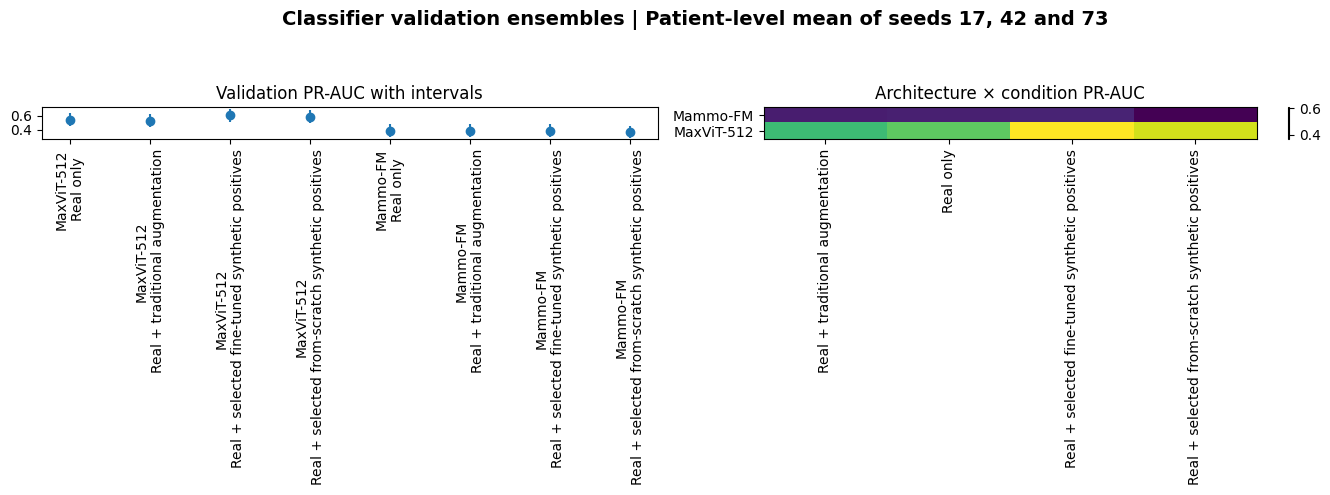

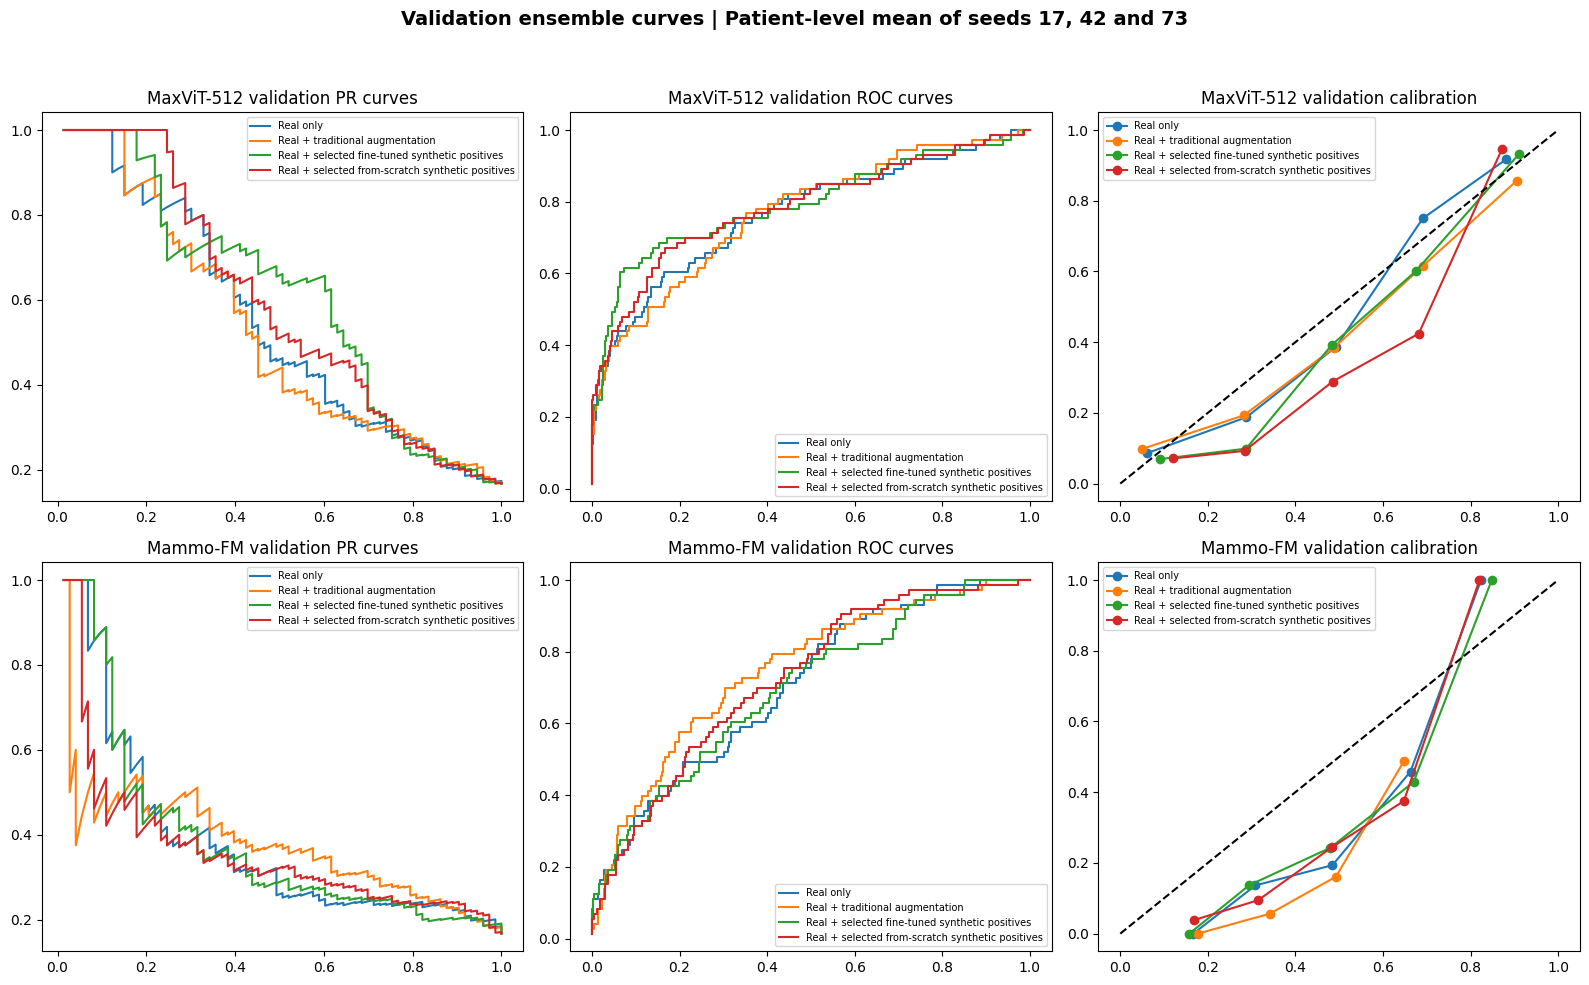

In [9]:
overview_figure = plot_ensemble_overview(ensembles) if ensembles is not None else None
curve_figure = plot_ensemble_curves(ROOT, ensembles) if ensembles is not None else None
(overview_figure, curve_figure) if overview_figure else 'Not yet evaluated — plots include PR-AUC intervals, ROC-AUC/Brier/ECE table, deltas vs real_only, seed mean/SD, heatmap, PR/ROC and calibration curves.'